In [10]:
import pandas as pd
data=pd.read_csv("train.csv")
test_data=pd.read_csv("test.csv")
new_data=data.dropna()

In [11]:
new_data.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
test_data.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)

In [12]:
main_data=new_data.drop('Survived',axis='columns')
target=new_data.Survived

In [13]:
main_data.Sex=main_data.Sex.map({'male':1,'female':2})
test_data.Sex=test_data.Sex.map({'male':1,'female':2})

In [14]:
main_data.Age[:10]

1     38.0
3     35.0
6     54.0
10     4.0
11    58.0
21    34.0
23    28.0
27    19.0
52    49.0
54    65.0
Name: Age, dtype: float64

In [15]:
main_data.Age=main_data.Age.fillna(main_data.Age.mean())
test_data.Age = test_data.Age.fillna(main_data.Age.mean())

In [16]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [17]:
model.fit(main_data,target)
model.score(main_data,target)

1.0

In [18]:
predictions = model.predict(test_data)

In [19]:
submission = pd.DataFrame({'PassengerId': pd.read_csv('test.csv')['PassengerId'], 'Survived': predictions})
submission.to_csv('submission2.csv', index=False)

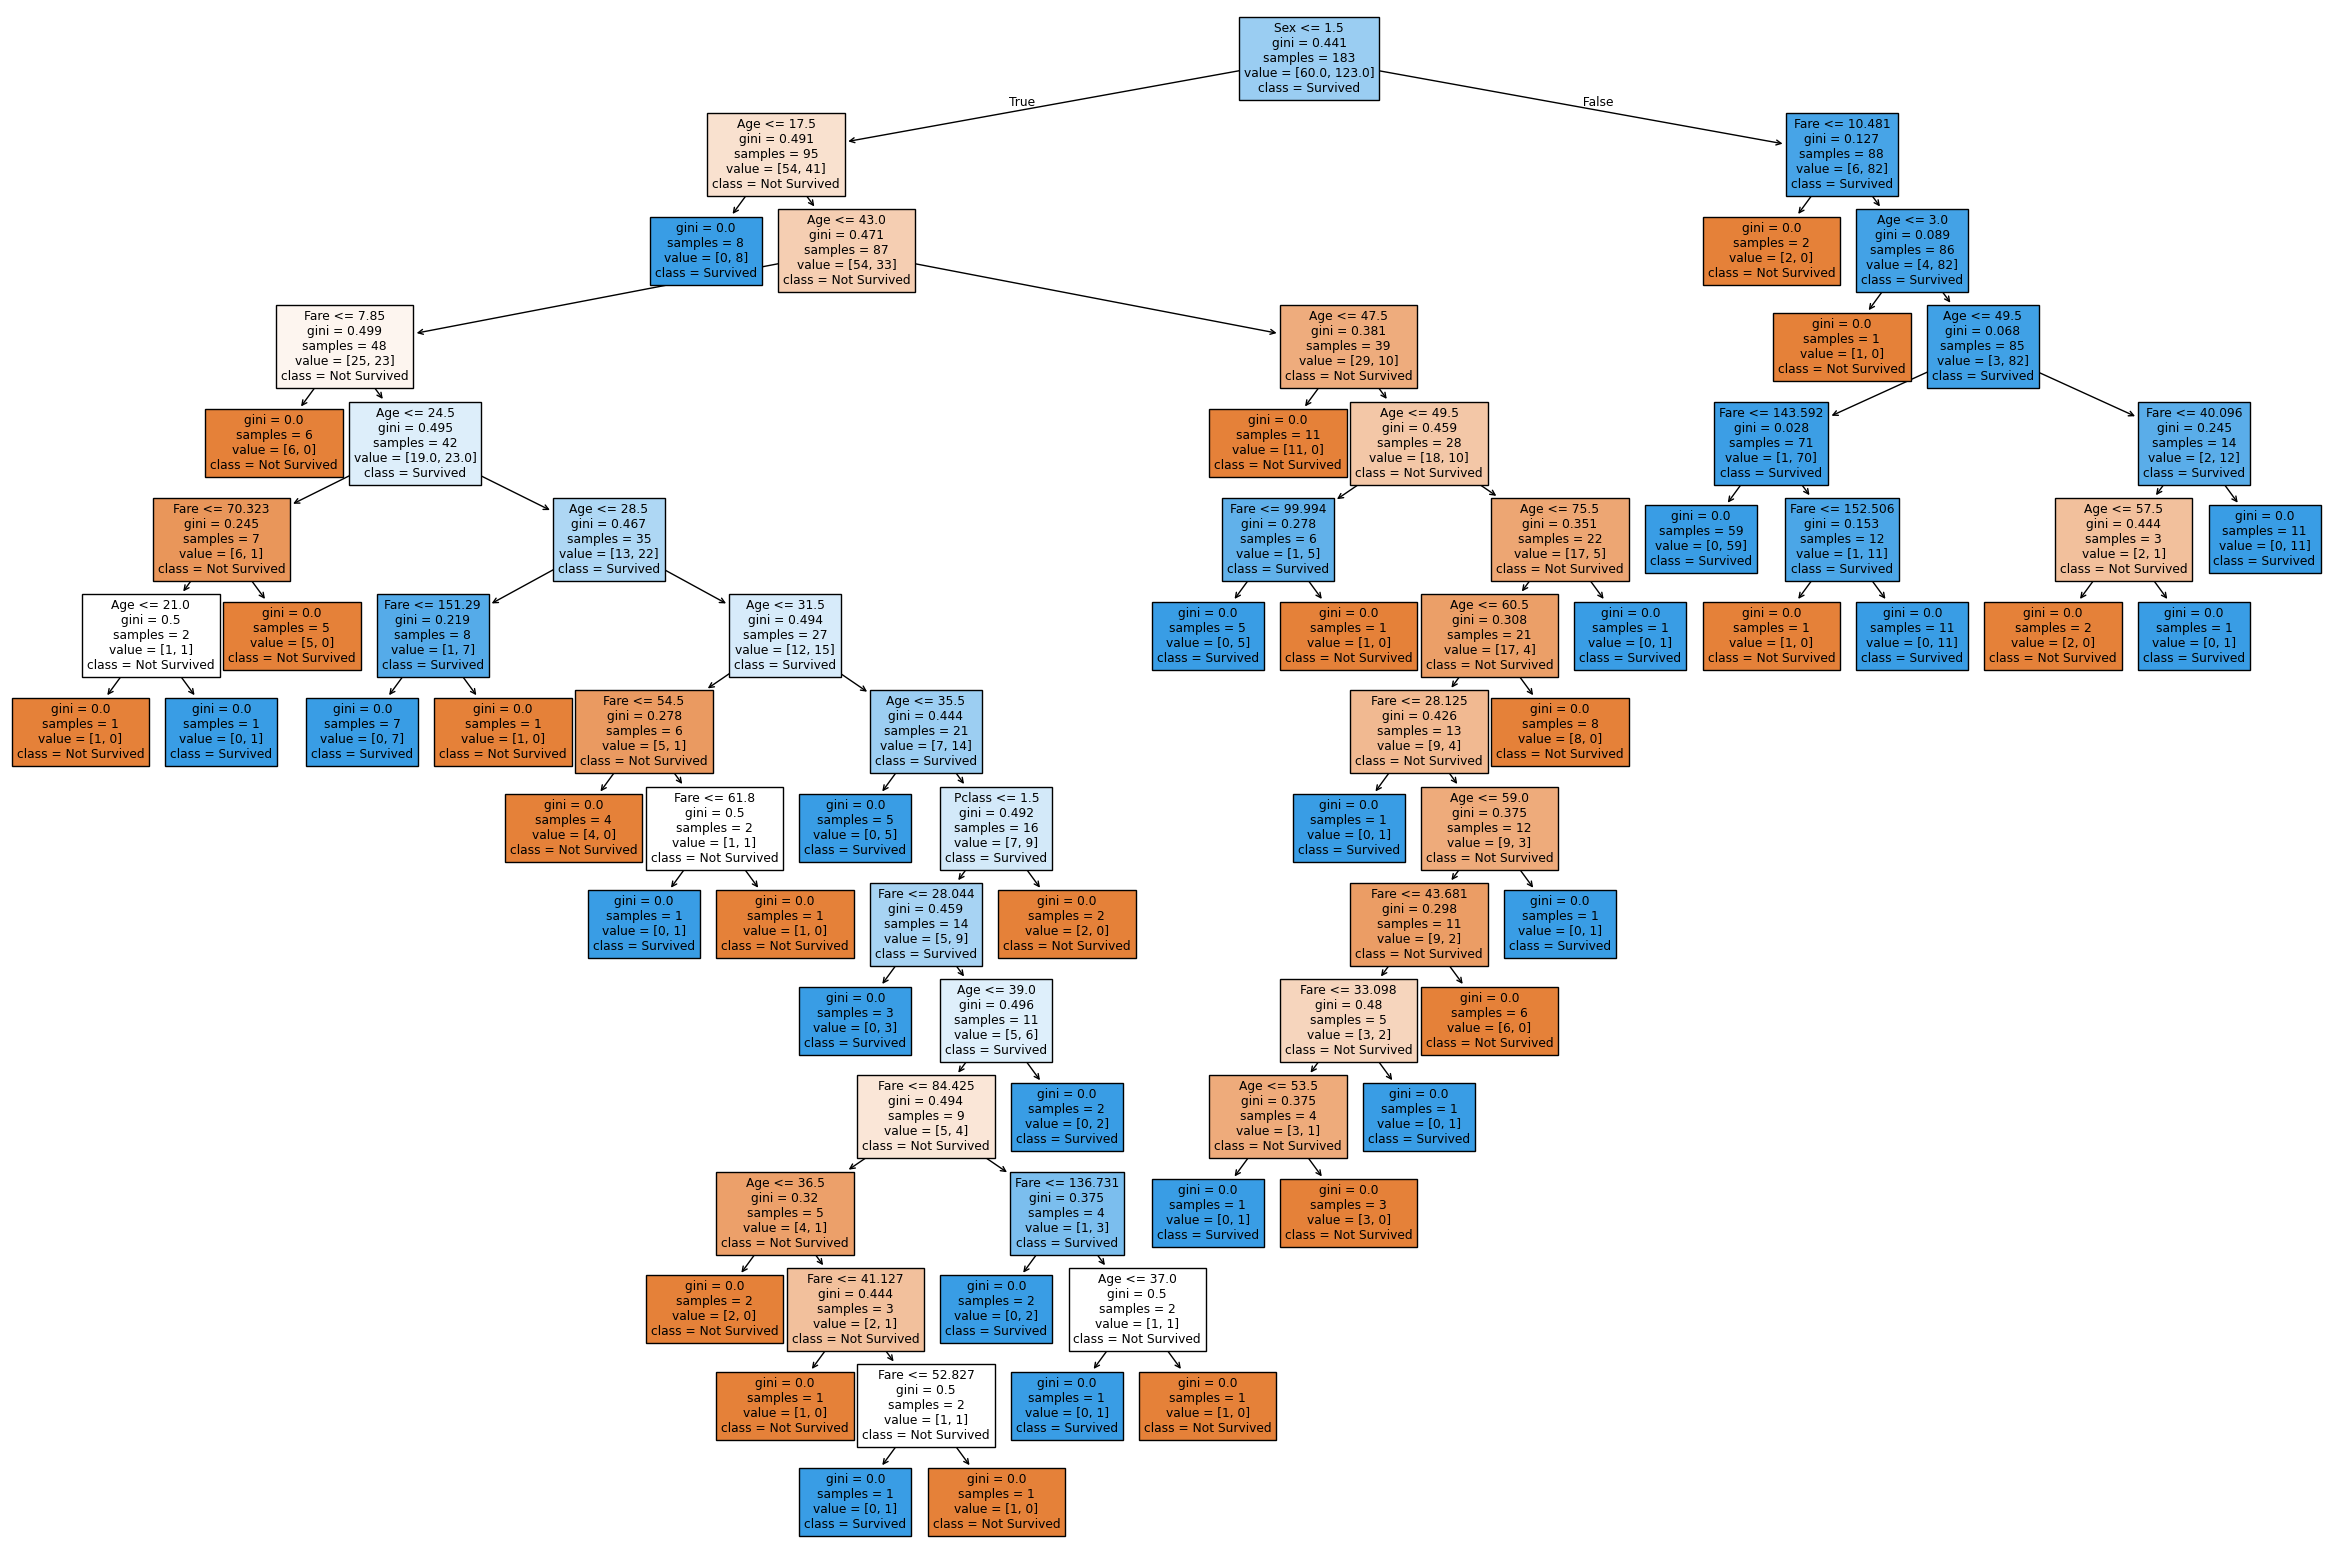

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,20))
plot_tree(model, feature_names=main_data.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()